# Building Simple and Multiple Regression Models with Regression Line and Residual Plots

**Objectives**
1. Build and interpret a simple linear regression model and visualize the regression line and residual points 
2. Extending same idea to multiple linear regression with severalm variables and evaluate it using resudual analysis. 
    simple linear regresion 
problem statem,ent
a shop want to predict the sales based on the advertising budget 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
data = {
    "Advertising": [10, 12, 15, 18, 20, 22, 25, 28, 30, 35],
    "Sales":       [25, 28, 30, 35, 37, 40, 44, 48, 50, 58]
}
df = pd.DataFrame(data)
print(df)

   Advertising  Sales
0           10     25
1           12     28
2           15     30
3           18     35
4           20     37
5           22     40
6           25     44
7           28     48
8           30     50
9           35     58


In [3]:
X_slr = df[["Advertising"]]   # 2D array required by sklearn
y_slr = df["Sales"]

slr = LinearRegression()
slr.fit(X_slr, y_slr)

print(f"Intercept  (b0): {slr.intercept_:.4f}")
print(f"Slope      (b1): {slr.coef_[0]:.4f}")
print(f"\nEquation: Sales = {slr.intercept_:.4f} + {slr.coef_[0]:.4f} × Advertising")

Intercept  (b0): 11.4605
Slope      (b1): 1.3042

Equation: Sales = 11.4605 + 1.3042 × Advertising


In [4]:
# Predictions and Residuals (SLR) 
df["Predicted_Sales"] = slr.predict(X_slr)
df["Residual"]        = df["Sales"] - df["Predicted_Sales"]
print(df.to_string(index=False))

 Advertising  Sales  Predicted_Sales  Residual
          10     25        24.502124  0.497876
          12     28        27.110450  0.889550
          15     30        31.022940 -1.022940
          18     35        34.935429  0.064571
          20     37        37.543755 -0.543755
          22     40        40.152082 -0.152082
          25     44        44.064571 -0.064571
          28     48        47.977060  0.022940
          30     50        50.585387 -0.585387
          35     58        57.106202  0.893798


In [6]:
r2_slr  = r2_score(y_slr, df["Predicted_Sales"])
mse_slr = mean_squared_error(y_slr, df["Predicted_Sales"])

print(f"R² Score : {r2_slr:.4f}  → model explains {r2_slr*100:.2f}% of variance in Sales")
print(f"MSE      : {mse_slr:.4f}")

R² Score : 0.9965  → model explains 99.65% of variance in Sales
MSE      : 0.3555


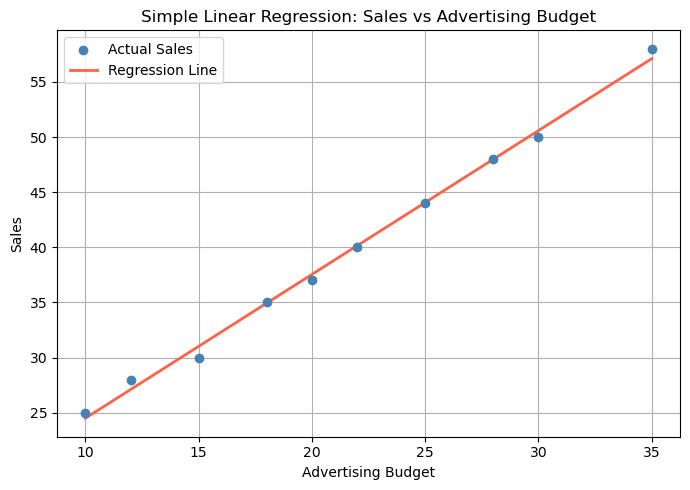

In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Advertising"], df["Sales"],
            color="steelblue", label="Actual Sales", zorder=3)
plt.plot(df["Advertising"], df["Predicted_Sales"],
         color="tomato", linewidth=2, label="Regression Line")
plt.title("Simple Linear Regression: Sales vs Advertising Budget")
plt.xlabel("Advertising Budget")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

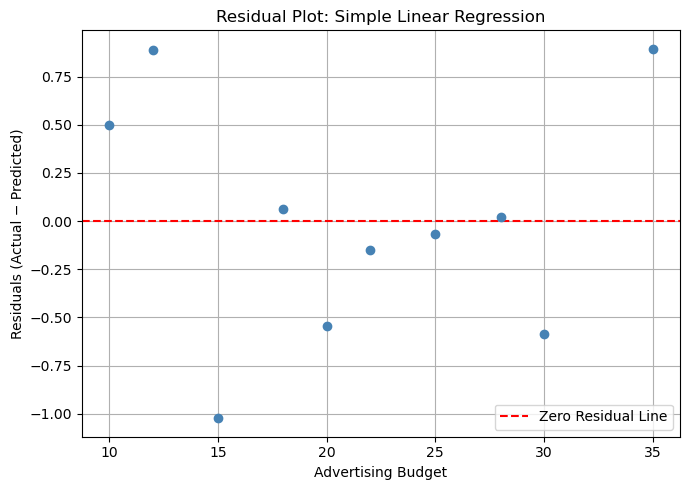

In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Advertising"], df["Residual"],
            color="steelblue", zorder=3)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5, label="Zero Residual Line")
plt.title("Residual Plot: Simple Linear Regression")
plt.xlabel("Advertising Budget")
plt.ylabel("Residuals (Actual − Predicted)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Multiple Linear Regression (Several Input Values)

## Problem Statement

Predicting **Sales** using:

1. **Advertising budget**
2. **Product Price**
3. **Number of Salesperson**


In [9]:
data2 = {
    "Advertising": [10, 12, 15, 18, 20, 22, 25, 28, 30, 35],
    "Price":       [110, 105, 108, 100, 98, 95, 92, 90, 88, 85],
    "Salespeople": [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    "Sales":       [25, 28, 30, 35, 37, 40, 44, 48, 50, 58]
}
df2 = pd.DataFrame(data2)
print(df2)

   Advertising  Price  Salespeople  Sales
0           10    110            2     25
1           12    105            2     28
2           15    108            3     30
3           18    100            3     35
4           20     98            3     37
5           22     95            4     40
6           25     92            4     44
7           28     90            4     48
8           30     88            5     50
9           35     85            5     58


In [10]:
X_multi = df2[["Advertising", "Price", "Salespeople"]]
y_multi = df2["Sales"]

mlr = LinearRegression()
mlr.fit(X_multi, y_multi)

print(f"Intercept      (b0): {mlr.intercept_:.4f}")
print(f"Advertising    (b1): {mlr.coef_[0]:.4f}")
print(f"Price          (b2): {mlr.coef_[1]:.4f}")
print(f"Salespeople    (b3): {mlr.coef_[2]:.4f}")

Intercept      (b0): 19.6661
Advertising    (b1): 1.3827
Price          (b2): -0.0618
Salespeople    (b3): -1.1126


In [11]:
df2["Predicted_Sales"] = mlr.predict(X_multi)
df2["Residuals"]       = df2["Sales"] - df2["Predicted_Sales"]
print(df2.to_string(index=False))

 Advertising  Price  Salespeople  Sales  Predicted_Sales  Residuals
          10    110            2     25        24.470801   0.529199
          12    105            2     28        27.545143   0.454857
          15    108            3     30        30.395264  -0.395264
          18    100            3     35        35.037672  -0.037672
          20     98            3     37        37.926641  -0.926641
          22     95            4     40        39.764816   0.235184
          25     92            4     44        44.098268  -0.098268
          28     90            4     48        48.369929  -0.369929
          30     88            5     50        50.146313  -0.146313
          35     85            5     58        57.245152   0.754848


# Evaluating Model Performance 

In [12]:
r2_mlr  = r2_score(y_multi, df2["Predicted_Sales"])
mse_mlr = mean_squared_error(y_multi, df2["Predicted_Sales"])

print(f"R² Score : {r2_mlr:.4f}  → model explains {r2_mlr*100:.2f}% of variance in Sales")
print(f"MSE      : {mse_mlr:.4f}")

R² Score : 0.9977  → model explains 99.77% of variance in Sales
MSE      : 0.2296


# Residual Plot (Multiple Regression)

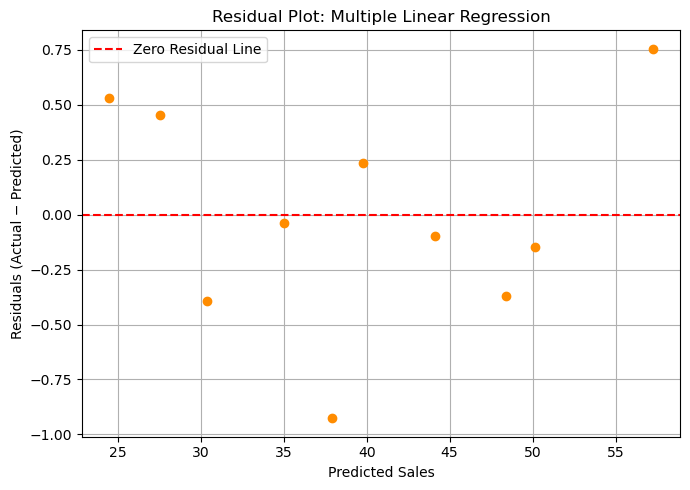

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(df2["Predicted_Sales"], df2["Residuals"],
            color="darkorange", zorder=3)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5, label="Zero Residual Line")
plt.title("Residual Plot: Multiple Linear Regression")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals (Actual − Predicted)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
new_input = pd.DataFrame({
    "Advertising": [26],
    "Price":       [93],
    "Salespeople": [4]
})

predicted = mlr.predict(new_input)
print(f"Predicted Sales for Advertising=26, Price=93, Salespeople=4: ")

Predicted Sales for Advertising=26, Price=93, Salespeople=4: 
